# Heating and  adiabatic humidification with controlled air flow and recirculated air 

This project deals with heating and adiabatic humidification of Constant Air Volume (CAV) HVAC systems. The aim is to provide an indoor farming with the needed conditions for the plants to grow. The infow air will be provided from a climate chamber, situated in a different zone with a constant temperature of $\theta_{amb}$ = 15 °C and a constant relative humidity of $\phi_{amb}$ = 90 %. To provide the needed conditions, the air flow in the adiabatic humidification is being controlled. 

## Schematics of the System

![winter_AdHum_Rec_CAV](./Figures/heat_AdHum_Rec_CAV.svg)

> Figure 1. Heating and adiabatic humidification in an air recirculation CAV system with an AHU serving one thermal zone.

> Table 1. Widgets to modify the operation of the HVAC system.

|Widget| Symbol         |          | Unit| Meaning                               |
|------|----------------|----------|-----|---------------------------------------|
|`α`   |$\alpha$        |      |     |Proportion of outdoor air in the supply air|
|`β`   |$\beta$         |      |     |By-pass factor of the adiabatic humidifier AH  |   
|`θS`  |$\theta_S^{sp}$ |$\theta_2^{sp}$| °C|Set-point for supply air temperature   |
|`θIsp`|$\theta_I^{sp}$ |$\theta_3^{sp}$| °C|Set-point for indoor air temperature   |
|`φIsp`|$\varphi_I^{sp}$|$\varphi_3^{sp}$|  |Set-point for indoor relative humidity |
|`θO`  |$\theta_O$      |$\theta_0$| °C  |Outdoor air temperature                |
|`φO`  |$\varphi_O$     |$\varphi_0$|    |Outdoor air relative humidity          |

> Table 2. Widgets to modify the characteritics of the building.

|Widget| Symbol         | Unit| Meaning                                   |
|------|----------------|-----|-------------------------------------------|
|`Qsa` |$\dot{Q}_{s,a}$ | W   |Auxiliary sensible heat of the thermal zone|
|`Qla` |$\dot{Q}_{l,a}$ | W   |Auxiliary latent heat of the thermal zone|
|`mi`  |$\dot{m}_i$     | kg/s|Mass flow rate of air infiltration into the thermal zone|
|`UA`  |$U A$           | W/°C|Overall thermal conductance of the thermal zone|

Optimal β:  0.360
Error (w):  2.201e-09 kg/kg
m =  4.933 kg/s constant for design conditions:
    [θSd =  30.0 °C, mi =  1.000 kg/s, θO =  15.0°C, φ0 =  0.8]


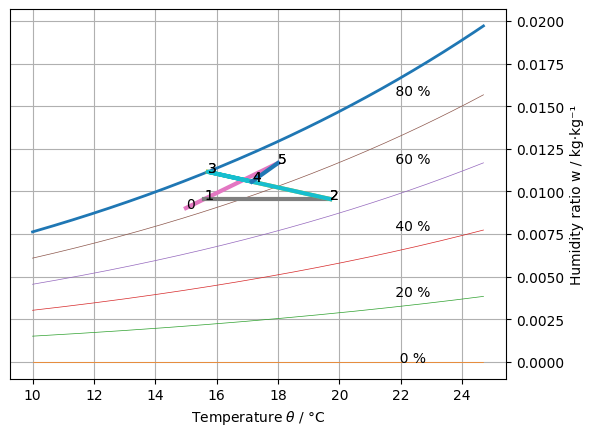


   θ [°C] w [g/kg]
0   15.00     9.03
1   15.60     9.56
2   19.71     9.56
3   15.71    11.15
4   17.15    10.58
5   18.00    11.67

   QsHC1  QsTZ  QlTZ
0  20.25  4.19 13.41 kW


(0   15.00
 1   15.60
 2   19.71
 3   15.71
 4   17.15
 5   18.00
 dtype: float64,
 0    9.03
 1    9.56
 2    9.56
 3   11.15
 4   10.58
 5   11.67
 dtype: float64,
 QsHC1   20,252.56
 QsTZ     4,192.51
 QlTZ    13,408.78
 dtype: float64)

In [ ]:
from HVAC_model import RecAirCAV
from CoolProp.HumidAirProp import HAPropsSI
from scipy.optimize import minimize

# Operating conditions
P = 101325


# Set points
θ_5_SP = 18
φ_5_SP = 0.9

w_5_SP = HAPropsSI("W", "T", θ_5_SP+273.15, "R", φ_5_SP, "P", P)

def objective(x):
    η, β = x
    θ, w, Q = RecAirCAV(
        α=0.8,
        η=η,
        β=β,
        θS=30,
        θO=15,
        φO=0.85,
        Qsa=10000,
        Qla=20000,
        mi=1.0,
        UA=935.83,
        show_plots=False,
        show_output=False
    )
    error_θ = abs(θ_5_SP - θ[5])
    error_w = abs(w_5_SP - w[5] / 1000)
    return error_θ + error_w  # Combined scalar objective

bounds = [(0, 1), (0, 1)]  # bounds for η and β respectively
x0 = [0.5, 0.5]            # initial guess

result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)

η_opt, β_opt = result.x
print(f"Optimal η:  {η_opt:.3f}")
print(f"Optimal β:  {β_opt:.3f}")
print(f"Final error: {result.fun:.3e}")

RecAirCAV(
        α=0.8,
        β=β_opt,
        θS=30,
        θO=15,
        φO=0.85,
        Qsa=10000,
        Qla=20000,
        mi=1.0,
        UA=935.83,
        show_plots=True,
        show_output=True
    )

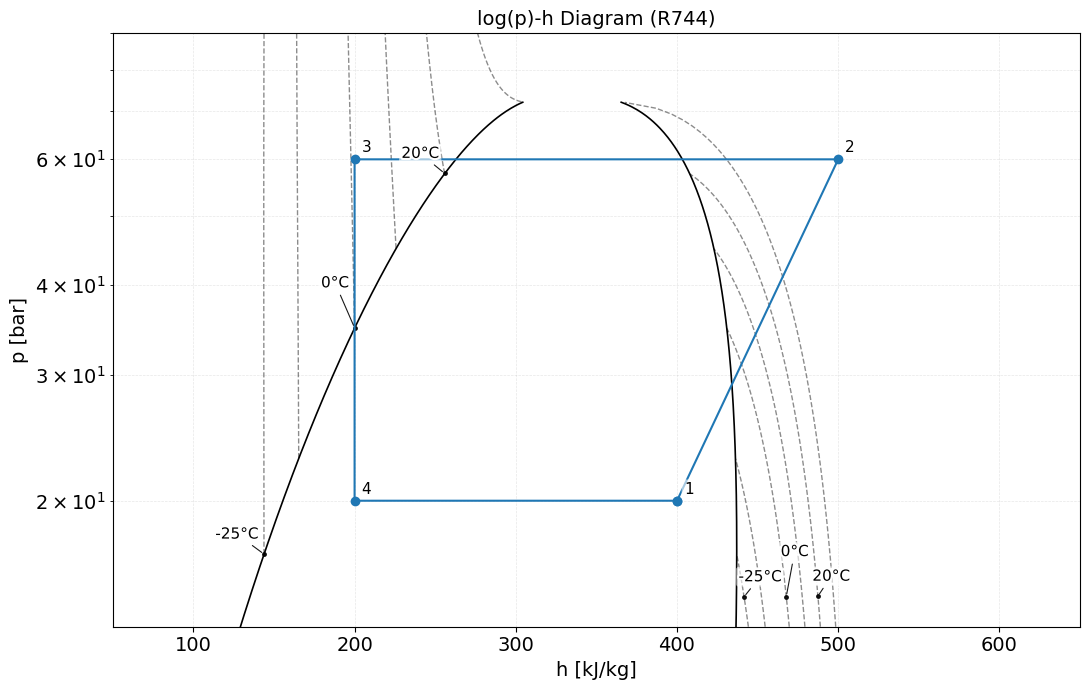

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'log(p)-h Diagram (R744)'}, xlabel='h [kJ/kg]', ylabel='p [bar]'>)

In [2]:
from plotting import plot_logph_cycles

cycle = [[2000000, 400000], [6000000, 500000], [6000000, 200000], [2000000, 200000]]

plot_logph_cycles(ref="R744",
                  t=[None],
                  cycle_ph=[cycle],
                  isotherms=True,
                  #iso_Ts_C=[-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100],
                  #xlim=[200,475],
                  #ylim=[1,20]
                  )